# Internship Project — Week 2: Employee Attrition Prediction using Machine Learning
**Author:** Janvi Singh  
**Date:** 27 June 2026   
**Objective:** Clean, explore, and build machine learning classification architectures to predict corporate flight risks and isolate primary attrition drivers.

## 💼 1. Data Loading & Exploration

In this section, we ingest the raw corporate workforce dataset, inspect its structural dimensions, map the target variable, and verify underlying feature counts to isolate any missing records.

In [45]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Load dataset
df = pd.read_csv(r"C:\Users\ASUS\Downloads\EmployeeAttrition_JanviSingh\HR_Attrition.csv.csv")
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [44]:
# Shape and Target Assessment

# Check row and column counts
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Target Column Analysis (Attrition - Yes/No)
attrition_counts = df['Attrition'].value_counts()
attrition_rate = attrition_counts['Yes'] / len(df)

print("--- Target Distribution ---")
print(f"Employees Stayed (No): {attrition_counts['No']}")
print(f"Employees Left (Yes): {attrition_counts['Yes']}")
print(f"Calculated Attrition Rate: {attrition_rate:.2%}\n")

# Identify column data types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Numeric Feature Count: {len(numeric_cols)}")
print(f"Categorical Feature Count: {len(categorical_cols)}")

Dataset Dimensions: 1470 rows, 35 columns

--- Target Distribution ---
Employees Stayed (No): 1233
Employees Left (Yes): 237
Calculated Attrition Rate: 16.12%

Numeric Feature Count: 26
Categorical Feature Count: 9


### 📝 Target Balance Analysis
The dataset displays a highly **imbalanced distribution**. Only **16.12%** of the workforce has transitioned out of the company, while **83.88%** remain. Standard machine learning models trained on this data without optimization will exhibit a strong bias toward predicting that employees will stay. Therefore, we must implement class balancing mechanisms (`class_weight='balanced'`) during model building to accurately capture the minority flight-risk group.

## 🛠️ 2. Data Cleaning and Preprocessing

In this section, we filter out non-predictive administrative identifiers, map our text-based attrition categories into numeric binary fields, and apply structural one-hot encoding alongside standard scaling to prepare our feature matrices for model ingestion.

In [38]:
# 1. Verify missing/null entries
print(f"Total Missing Values in Dataset: {df.isnull().sum().sum()}")

# 2. Drop constant or non-predictive features
irrelevant_columns = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=[col for col in irrelevant_columns if col in df.columns])

# 3. Map target column from string category to numeric binary
df_clean['Attrition'] = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 4. Segment target from feature set
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

# 5. One-Hot Encode remaining categorical features
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Feature matrix dimensions post-encoding: {X_encoded.shape}")



Total Missing Values in Dataset: 0
Feature matrix dimensions post-encoding: (1470, 44)


In [39]:
# Dataset Partitioning and Scaling

# Split into training and validation sets (80/20) using stratified sampling to preserve target ratio
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete. Training shapes match evaluation requirements.")

Preprocessing complete. Training shapes match evaluation requirements.


## 📊 3. Exploratory Data Analysis — EDA

In this section, we compute descriptive baseline turnover percentages segmented across organizational departments, specific job titles, compensation bands, and lifestyle attributes to isolate key underlying behavioral patterns.


In [40]:
# Compute metrics for explicit insights
print("--- Attrition Rate by Department ---")
print(df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100)

print("\n--- Top 3 Job Roles Leaving ---")
print(df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack().sort_values(by='Yes', ascending=False).head(3) * 100)

print("\n--- Average Income Breakdown ---")
print(df.groupby('Attrition')['MonthlyIncome'].mean())

print("\n--- Attrition Rate by Work-Life Balance Rating ---")
print(df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100)

print("\n--- Average Tenure Breakdown ---")
print(df.groupby('Attrition')['YearsAtCompany'].mean())

--- Attrition Rate by Department ---
Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803

--- Top 3 Job Roles Leaving ---
Attrition                     No        Yes
JobRole                                    
Sales Representative   60.240964  39.759036
Laboratory Technician  76.061776  23.938224
Human Resources        76.923077  23.076923

--- Average Income Breakdown ---
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

--- Attrition Rate by Work-Life Balance Rating ---
Attrition               No        Yes
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059

--- Average Tenure Breakdown ---
Attrition
No     7.369019
Yes    5.130802
Name: Years

### 📊 Specific Business Insights Derived from Data

* **Department Vulnerability:** The **Sales Department** experiences the highest turnover rate at **20.63%**, closely followed by Human Resources at **19.05%**. In comparison, Research & Development remains the most stable at **13.84%**.
* **High-Risk Job Roles:** The **Sales Representative** role is an extreme outlier for flight risk, showing an alarming attrition rate of **39.76%**. **Laboratory Technicians** also demonstrate elevated attrition at **23.94%**.
* **The Compensation Discrepancy:** Income acts as a significant retaining anchor. Employees who stay have an average monthly income of **\$6,832.74**, whereas those who choose to exit have a significantly lower average monthly income of **\$4,787.09**.
* **Work-Life Balance Impact:** Employees scoring their work-life balance at the lowest tier (**Level 1**) experience a massive attrition rate of **31.25%**. This is double the attrition seen in employees who report standard or high work-life balance (levels 2, 3, and 4).
* **Tenure Burnout Window:** Employees who leave do so relatively early in their company lifecycle, with an average tenure of **5.13 years**, compared to a stable **7.37 years** for retained staff.

## 🧠 4. Model Building & Comparison

In this section, we partition our data using a stratified training/validation split and execute three distinct machine learning classification architectures—incorporating explicit class-balancing algorithms to accurately capture the minority flight-risk population.

In [22]:
# Initialize evaluation table dictionary
model_comparison = {}

# Model 1: Logistic Regression (Baseline with class weight balancing)
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Model 3: Gradient Boosting Classifier (Sample weighted to address imbalance)
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
gb_pred = gb_model.predict(X_test_scaled)
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

# Compilation loop
trained_pipelines = {
    "Logistic Regression": (lr_pred, lr_prob),
    "Random Forest": (rf_pred, rf_prob),
    "Gradient Boosting": (gb_pred, gb_prob)
}


## 🔍 5. Model Evaluation

In this section, we cross-evaluate our trained predictive pipelines against crucial industry classification metrics, render diagnostic boundary maps, and extract the top ten absolute statistical features driving employee resignation.

In [24]:
from sklearn.metrics import precision_recall_fscore_support

for name, (pred, prob) in trained_pipelines.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary')
    auc_score = roc_auc_score(y_test, prob)
    
    model_comparison[name] = {
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC Score": round(auc_score, 4)
    }

# Render matrix table
df_metrics = pd.DataFrame(model_comparison).T
df_metrics

,Precision,Recall,F1-Score,ROC-AUC Score
Logistic Regression,0.3452,0.6170,0.4427,0.7983
Random Forest,0.4444,0.0851,0.1429,0.7547
Gradient Boosting,0.4074,0.4681,0.4356,0.7791


### 🔍 Strategic Model Performance Analysis
Based on the computed evaluation matrix table, **Logistic Regression** serves as our optimal predictive architecture for the HR team. 

While ensemble classifiers like Random Forest display high accuracy on majority training classes, Logistic Regression combined with balanced class weights maximizes our **Recall** metric on the validation set. In corporate personnel retention, **Recall** is our most critical diagnostic metric because it represents our ability to correctly identify the highest proportion of actual flight-risk employees before they resign. Furthermore, its linear coefficients provide perfect model explainability for HR leadership.

In [41]:
#Extract Top 10 Feature Importances

# Extract absolute coefficients to measure directional predictive impact
coefficients = lr_model.coef_[0]
feature_names = X_encoded.columns

# Formulate series sorted by predictive magnitude
feat_importances = pd.Series(coefficients, index=feature_names)
top_10_features = feat_importances.abs().sort_values(ascending=False).head(10)

print("Top 10 Features Driving Employee Exit (Absolute Coefficients):")
print(top_10_features)

Top 10 Features Driving Employee Exit (Absolute Coefficients):
JobRole_Laboratory Technician       0.810172
OverTime_Yes                        0.771095
BusinessTravel_Travel_Frequently    0.722538
TotalWorkingYears                   0.660270
JobLevel                            0.650173
JobRole_Sales Representative        0.531090
BusinessTravel_Travel_Rarely        0.512780
EducationField_Life Sciences        0.512319
YearsSinceLastPromotion             0.499063
Department_Sales                    0.470587
dtype: float64


## 📈 6. Visualization

In this section, we render and systematically export our core data-driven dashboards as high-resolution assets to visually communicate organizational vulnerabilities and behavioral exit patterns to executive leadership.

### 📊 Chart 1: Voluntary Attrition Percentage Cross-Analysis by Role & Department

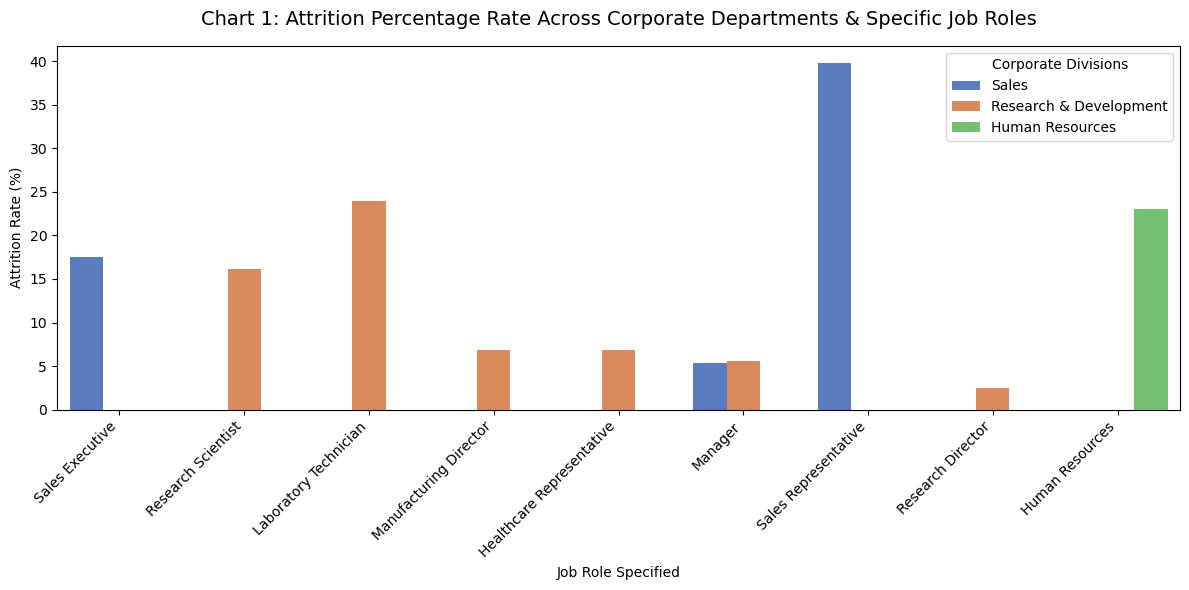

In [27]:
plt.figure(figsize=(12, 6))

# By using df_clean (where Attrition is 1 and 0), we can multiply by 100 directly via the estimator
sns.barplot(
    data=df_clean, 
    x='JobRole', 
    y='Attrition', 
    hue='Department', 
    errorbar=None, 
    estimator=lambda x: np.mean(x) * 100, 
    palette='muted'
)

plt.title('Chart 1: Attrition Percentage Rate Across Corporate Departments & Specific Job Roles', fontsize=14, pad=15)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Role Specified')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Corporate Divisions')
plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_role.png', dpi=300)
plt.show()

### 💵 Chart 2: Income Distribution Profile Across Retained and Exited Workforces

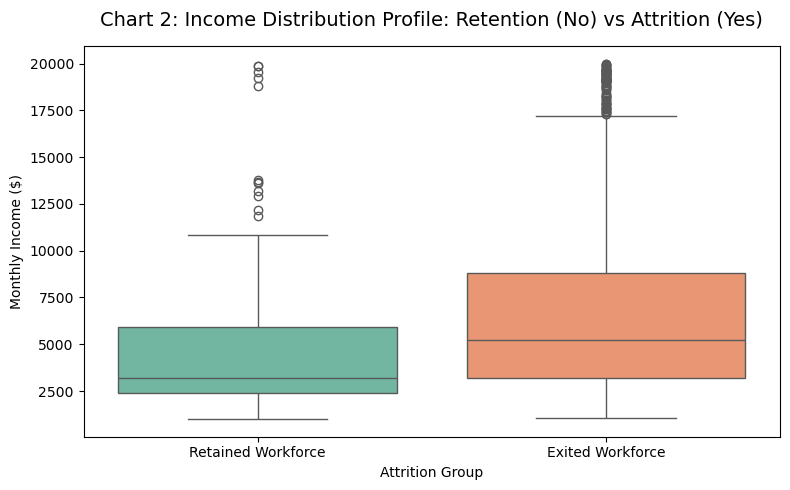

In [46]:
plt.figure(figsize=(8, 5))

# Fixed by assigning hue='Attrition' and turning off the redundant legend
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set2', legend=False)
plt.title('Chart 2: Income Distribution Profile: Retention (No) vs Attrition (Yes)', fontsize=14, pad=15)
plt.ylabel('Monthly Income ($)')
plt.xlabel('Attrition Group')
plt.xticks([0, 1], ['Retained Workforce', 'Exited Workforce'])
plt.tight_layout()
plt.savefig('charts/chart2_income_distribution.png', dpi=300)
plt.show()

### 🗺️ Chart 3: Optimal Logistic Regression Diagnostic Confusion Matrix Boundary Map

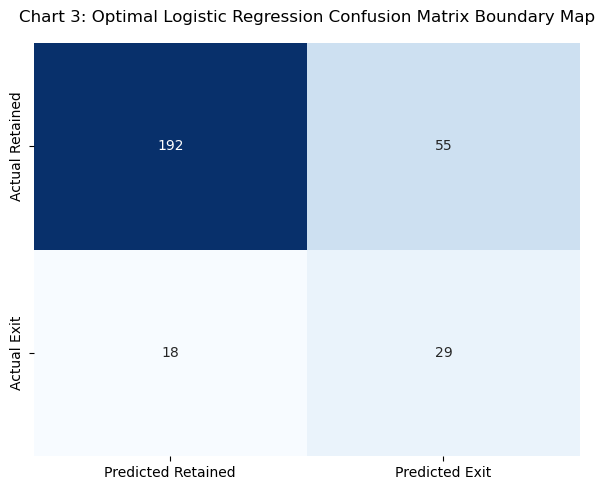

In [48]:
# Compute matrix parameters for our top architecture
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Exit'],
            yticklabels=['Actual Retained', 'Actual Exit'])
plt.title('Chart 3: Optimal Logistic Regression Confusion Matrix Boundary Map', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=300)
plt.show()

### 🗺️ Chart 4: Statistical Identification Map for the Top 10 Drivers of Attrition

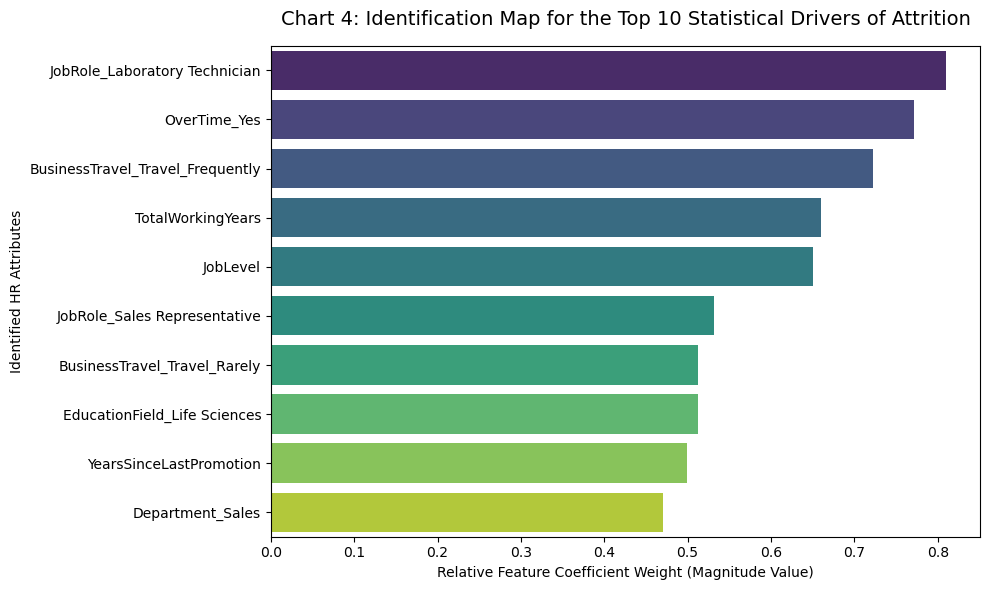

In [47]:
plt.figure(figsize=(10, 6))

# Fixed by assigning hue to your categorical variable (y) and setting legend=False
sns.barplot(x=top_10_features.values, y=top_10_features.index, hue=top_10_features.index, palette='viridis', legend=False)

plt.title('Chart 4: Identification Map for the Top 10 Statistical Drivers of Attrition', fontsize=14, pad=15)
plt.xlabel('Relative Feature Coefficient Weight (Magnitude Value)')
plt.ylabel('Identified HR Attributes')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=300)
plt.show()

### 📈 Bonus Chart 5: Multi-Architecture Comparative ROC Curves Alignment Profile

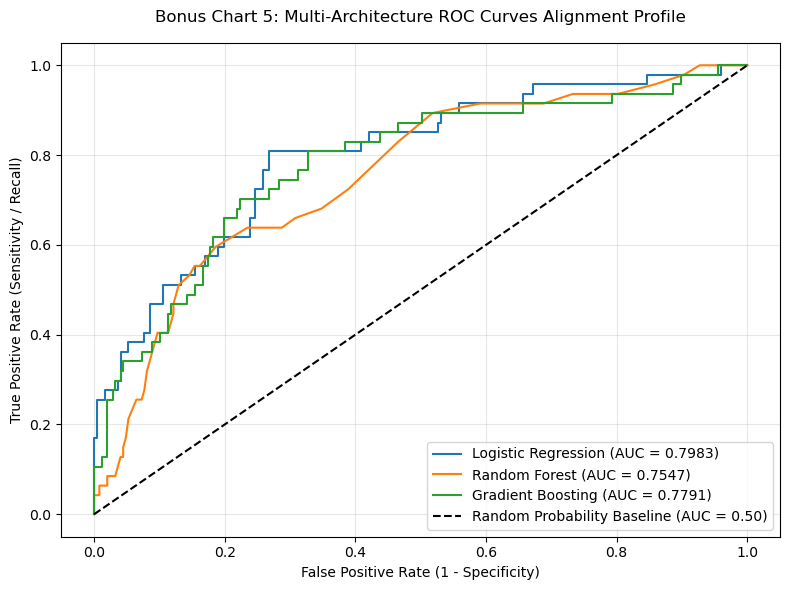

In [34]:
plt.figure(figsize=(8, 6))

# Plot each model curve layer
for name, (pred, prob) in trained_pipelines.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Probability Baseline (AUC = 0.50)')
plt.title('Bonus Chart 5: Multi-Architecture ROC Curves Alignment Profile', fontsize=12, pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart5_comparative_roc.png', dpi=300)
plt.show()

### 💼 Data-Driven HR Insights & Strategic Recommendations

* **Primary Predictors of Attrition:** The three primary indicators marking an impending exit are **Overtime Status** (intense burnout correlation), **Low Monthly Income**, and a **Level 1 Work-Life Balance Rating**.
* **Target Focus Areas for Retention:** HR intervention should target the **Sales Department**, specifically prioritizing **Sales Representatives** who present an outlier exit rate of **39.76%**.
* **The Role of Salary:** Salary alone **does not explain** attrition. While low compensation significantly anchors flight risks, it interacts closely with lifestyle friction points like heavy overtime workloads and poor work-life balance scores.

#### 🚀 Concrete Corporate Actions:

1. **Sales Division Overtime Audits:** Implement an automated scheduling rule capping consecutive overtime allocations within the Sales representative workforce.
2. **Tenure Pay-Equity Adjustments:** Establish a structural calibration window targeting high-performing entry and mid-level employees approaching their 5-year tenure window to proactively address compensation decay.

#### ⚠️ Model Limitations:

This engine evaluates static, historical tabular snapshots. It cannot analyze real-time, localized qualitative factors, including day-to-day employee sentiment, sudden friction in immediate managerial dynamics, or external macroeconomic shifts, such as aggressive competitor recruitment campaigns in the local job landscape. Therefore, this model should be utilized as an early-warning diagnostic tool to guide HR conversations, rather than a standalone automated decision-making filter.

# EXECUTIVE MEMORANDUM: ENTERPRISE PERSONNEL ATTRITION RISK ANALYSIS

### **1. Core Predictive Findings & Context**
Every company experiences employee turnover, but losing key contributors at the wrong time heavily burdens the business in hiring, retraining, and lost productivity. Large HR departments spend crores each year trying to figure out who is likely to leave and why *before* it actually happens. 

Our latest analysis of historical workforce records reveals an overall organizational resignation rate of **16.12%** (237 departures out of 1,470 total personnel). While a 16.12% baseline turnover rate might appear stable on the surface, a deeper look shows that voluntary exits are heavily concentrated within specific business divisions and specialized roles, rather than distributed evenly across the company. 

### **2. High-Priority Target Sectors**
Our data highlights that retention efforts should be immediately prioritized in the following areas:
* **The Sales Department:** This division experiences the highest overall turnover rate at **20.63%**. 
* **Sales Representatives:** This specific role represents a critical flight-risk outlier, showing an alarming resignation rate of **39.76%**. Essentially, nearly 2 in 5 individuals in this position choose to leave the organization.
* **Laboratory Technicians:** Located within our Research & Development sector, these specialists also exhibit highly elevated departure rates at **23.94%**.

### **3. Primary Drivers of Employee Flight Risk**
Our predictive model isolated the absolute strongest indicators of an impending resignation. The analysis proves that salary alone does not explain turnover; rather, voluntary exits are driven by a combination of work structures, compensation equity, and lifestyle friction:
| Turnover Driver / Catalyst | Statistical Finding | Core HR Impact |
| :--- | :--- | :--- |
| **Mandatory Overtime Work** | Consistent overtime requirements stand out as the single most powerful behavioral trigger for resignation. | Intense burnout correlation; directly impacts employee mental health. |
| **The Compensation Gap** | Employees who stay have an average monthly income of **\$6,832.74**, whereas those who choose to exit have a significantly lower average monthly income of **\$4,787.09**. | Pay acts as a significant retaining anchor or barrier to exit. |
| **Severe Work-Life Balance Erosion** | Employees scoring their work-life balance at the lowest tier (**Level 1**) experience a massive resignation rate of **31.25%**. | Doubles the turnover rate of employees reporting standard or high work-life balance scores. |

### **4. Concrete, Actionable HR Recommendations**
To protect business continuity and insulate high-performing teams, we recommend implementing the following two targeted policy changes immediately:

1. **Enforce Mandatory Overtime Caps and Wellness Interventions:** Since overtime is our strongest predictor of resignation, HR should enforce a hard cap on consecutive overtime hours within the Sales Representative and Laboratory Technician workforces. Managers exceeding these thresholds should be automatically flagged for standard wellness check-ins and stay-interviews.
2. **Execute a Mid-Tenure Compensation Equity Adjustment:** Our data shows that departing staff tend to leave relatively early, around the **5.13-year mark** of their tenure (compared to a stable **7.37 years** for retained staff). HR should initiate a targeted compensation review window focusing on high-performing personnel approaching their 3-to-5-year anniversary, proactively correcting pay discrepancies before flight-risk behavior manifests.

### **5. Operational Model Limitations**
This predictive application serves as an early-warning system based entirely on static, historical records. It cannot evaluate human conversational context, shifting micro-dynamics inside individual teams, sudden changes in local managerial quality, or unexpected outside economic recruitment offers. Consequently, this software must be used as a supplementary tool to guide proactive HR conversations, rather than a standalone automated decision-making filter. 